In [49]:
import pandas as pd
from PIL import Image
splits = {'train': 'mnist/train-00000-of-00001.parquet', 'test': 'mnist/test-00000-of-00001.parquet'}

In [50]:
#1.1

import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

data_path = "archive (1)/digits_jpeg/digits_jpeg" #from DIGITS Kaggle Set

bitmap_size = (7, 12)
average_bitmaps = {}

for digit in range(10):
    digit_folder = os.path.join(data_path, str(digit))  # Folder for each digit
    images = []
    
    for file_name in os.listdir(digit_folder):
        file_path = os.path.join(digit_folder, file_name)
        with Image.open(file_path).convert("L") as img:  # Convert to grayscale
            img_resized = img.resize(bitmap_size, Image.Resampling.LANCZOS)  # Resize to 7x12
            images.append(np.array(img_resized) / 255.0)  # Normalize pixel values to [0, 1]
    
    if images:
        average_bitmaps[digit] = np.mean(images, axis=0)  # Store as 7x12 bitmap

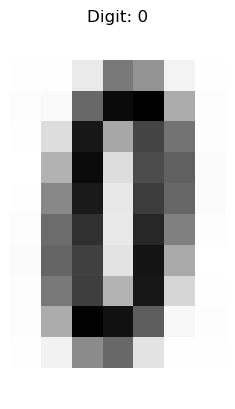

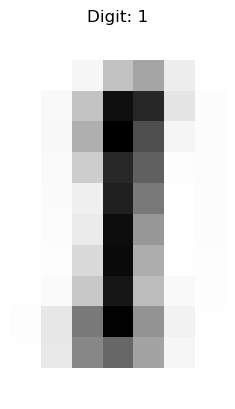

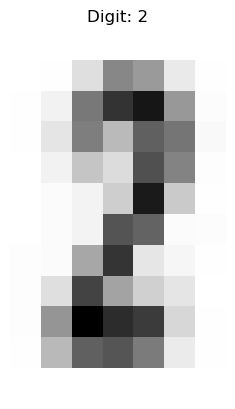

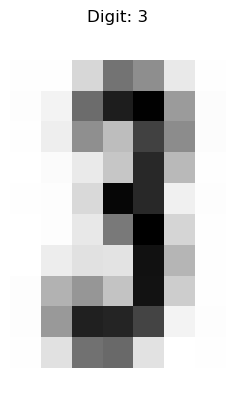

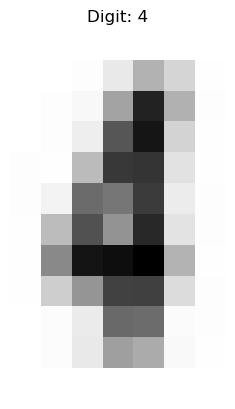

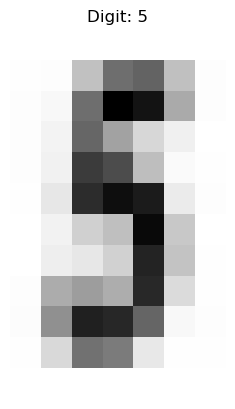

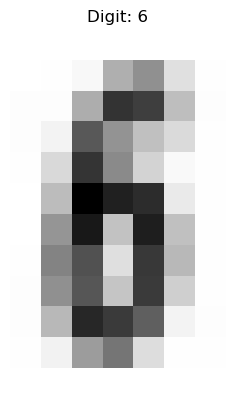

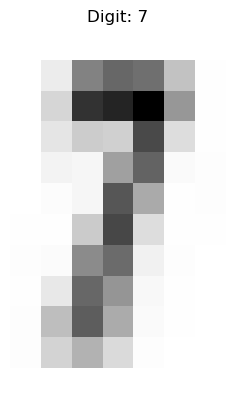

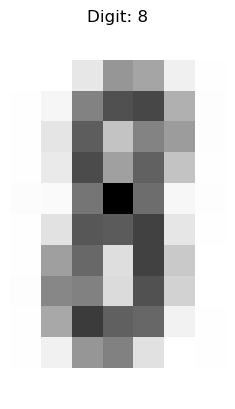

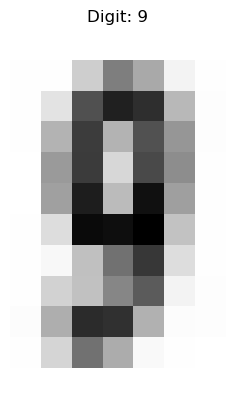

In [51]:
import matplotlib.pyplot as plt

for digit, bitmap in average_bitmaps.items():
    plt.imshow(bitmap, cmap="gray")
    plt.title(f"Digit: {digit}")
    plt.axis("off")
    plt.show()

#BITMAPS 7 x 12!!!

In [52]:
df_train = pd.read_parquet("hf://datasets/ylecun/mnist/" + splits["train"])
df_test = pd.read_parquet("hf://datasets/ylecun/mnist/" + splits["test"])

In [53]:
df_train.head()
#images in bytes and their "label"

,image,label
0,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,5
1,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,0
2,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,4
3,"{'bytes': b""\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...",1
4,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,9


In [54]:
print(len(df_train))
print(len(df_test))

60000
10000


In [55]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [56]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [57]:
prototypes = []
for digit, bitmap in average_bitmaps.items():
    vector = bitmap.flatten() #7x12 -> 1x84
    vector = (vector - np.mean(vector)) / np.std(vector)
    prototypes.append(torch.tensor(vector, dtype=torch.float32))

prototypes = torch.stack(prototypes).to(device) #get 10 vectors sized 1x84

In [58]:
def tanh_activation(x): #custom tangent function instead of sigmoid
    return 1.7159 * torch.tanh(2 * x / 3)

class RBFLayer(nn.Module):
    def __init__(self, prototypes):
        super(RBFLayer, self).__init__()
        self.prototypes = torch.nn.Parameter(prototypes, requires_grad=False) #use averaged digit bitmaps

    def forward(self, x):
        distances = torch.cdist(x.unsqueeze(0), self.prototypes.unsqueeze(0)).squeeze(0) #calculate distances from output of F6 and parameter
        return distances

class LeNet5RBF(nn.Module):
    def __init__(self, prototypes):
        super(LeNet5RBF, self).__init__()
        
        #C1, C3, S2, S4 
        self.conv1 = nn.Conv2d(1, 6, 5) #takes 32 x 32 -> 6 Feature Maps sized 28 x 28 (156 parameters)
        self.pool1 = nn.AvgPool2d(2, 2) #takes 28 x 28 -> 6 Feature Maps sized 14 x 14 (12 trainable parameters)
        self.conv2 = nn.Conv2d(6, 16, 5) #takes 14 x 14 -> 16 Feature Maps sized 10 x 10 
        self.pool2 = nn.AvgPool2d(2,2) #Takes 10 x 10 -> 16 Feature Maps sized 5 x 5 

        #Conv layers detect most significant features; each feature map has the same weights applied to it
        #weight sharing helps reduce difference between train and test 
        #max pool layers reduce spatial reslution (good for invariance to transformations)

        #C5: convolutional layer, takes in the 16 5x5 images
        self.fc1 = nn.Linear(16 * 5 * 5, 120) 

        #F6: fully connected
        self.fc2 = nn.Linear(120, 84)
        # RBF output layer
        self.rbf = RBFLayer(prototypes)
        
        # Initialize weights
        self._initialize_weights()
    
    def _initialize_weights(self):
        for layer in [self.conv1, self.conv2, self.fc1, self.fc2]:
            Fi = layer.weight.size(1) * layer.weight.size(2) if layer.weight.dim() > 2 else layer.weight.size(1)
            nn.init.uniform_(layer.weight, a=-2.4 / Fi, b=2.4 / Fi)
            if layer.bias is not None:
                nn.init.zeros_(layer.bias)
    
    def forward(self, x):
        x = tanh_activation(self.conv1(x))
        x = tanh_activation(self.pool1(x))
        
        x = tanh_activation(self.conv2(x))
        x = tanh_activation(self.pool2(x)) #400
        
        x = x.view(x.size(0), -1)  # Flatten

        x = tanh_activation(self.fc1(x)) #120
        x = tanh_activation(self.fc2(x)) #84 

        x = self.rbf(x) #10
        return x

In [59]:
def loss_fun(outputs, targets, j=0.1):
    #use equation 9 to get loss
    batch_size = outputs.size(0)
    c_distance = outputs[range(batch_size), targets]
    exp_neg_j = torch.exp(torch.tensor(-j, dtype=torch.float32, device=outputs.device)) #need j as tensor
    exp_neg_outputs = torch.exp(-outputs)
    mask = torch.ones_like(outputs, dtype=torch.bool)
    mask[range(batch_size), targets] = False
    exp_neg_incorrect = torch.sum(exp_neg_outputs * mask, dim=1) #for incorrect, sum

    penalty = torch.log(exp_neg_j + exp_neg_incorrect)
    loss = c_distance + penalty
    loss = torch.mean(loss)
    return loss

In [60]:
import pandas as pd
import numpy as np
from PIL import Image
import torch
from torch.utils.data import TensorDataset, DataLoader
import io

splits = {'train': 'mnist/train-00000-of-00001.parquet', 'test': 'mnist/test-00000-of-00001.parquet'}
df_train = pd.read_parquet("hf://datasets/ylecun/mnist/" + splits["train"])
df_test = pd.read_parquet("hf://datasets/ylecun/mnist/" + splits["test"])

def preprocess_mnist(dataframe):
    images = []
    labels = []
    for idx, row in dataframe.iterrows():
        img = Image.open(io.BytesIO(row['image']['bytes'])).convert("L")
        img_resized = img.resize((32, 32)) #need input to be 32x32
        img_array = np.array(img_resized) / 255.0 #0 - 255 for normalization
        images.append(img_array)
        labels.append(row['label'])
    
    images = np.array(images)  
    labels = np.array(labels)

    #make images and labels tensors for model
    images_tensor = torch.tensor(images, dtype=torch.float32).unsqueeze(1)
    labels_tensor = torch.tensor(labels, dtype=torch.long)
    return images_tensor, labels_tensor

train_images, train_labels = preprocess_mnist(df_train)
test_images, test_labels = preprocess_mnist(df_test)

train_dataset = TensorDataset(train_images, train_labels)
test_dataset = TensorDataset(test_images, test_labels)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=4, pin_memory=True)

In [61]:
#1.2 Model Training with Optimization

model = LeNet5RBF(prototypes).to(device) #load model
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
#SGD with step ~ 0.001 instead of second derivative for less computational cost

In [62]:
train_errors = [] 
test_errors = []
#track errors for future plotting

epochs = 20
#Training with batch size 1 and 20 epochs. Will take long due to small batch size and SGD
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()

        outputs = model(inputs) #take in images into model
        loss = loss_fun(outputs, targets) #loss is loss function defined previously from equation 9

        loss.backward()
        optimizer.step() #SGD

        running_loss += loss.item()
        preds = torch.argmin(outputs, dim=1)
        #minimize output distances to get predictions
        
        correct += (preds == targets).sum().item()
        total += targets.size(0)

    train_error = 100 - (100 * correct / total)
    train_errors.append(train_error)
    train_accuracy = 100 * correct / total

    model.eval()
    #for the test set evaluation
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs) #get labels for each test data
            preds = torch.argmin(outputs, dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)
    
    test_error = 100 - (100 * correct / total)
    test_errors.append(test_error)
    
    print(f"Train Accuracy: {train_accuracy:.2f}%")
    print(f"Epoch {epoch+1}/{epochs}, Train Error Rate: {train_error:.2f}%, Test Error Rate: {test_error:.2f}%")

Train Accuracy: 79.65%
Epoch 1/20, Train Error Rate: 20.35%, Test Error Rate: 4.45%
Train Accuracy: 95.93%
Epoch 2/20, Train Error Rate: 4.07%, Test Error Rate: 3.29%
Train Accuracy: 96.86%
Epoch 3/20, Train Error Rate: 3.14%, Test Error Rate: 2.87%
Train Accuracy: 97.32%
Epoch 4/20, Train Error Rate: 2.68%, Test Error Rate: 2.41%
Train Accuracy: 97.52%
Epoch 5/20, Train Error Rate: 2.48%, Test Error Rate: 1.99%
Train Accuracy: 97.73%
Epoch 6/20, Train Error Rate: 2.27%, Test Error Rate: 1.95%
Train Accuracy: 97.91%
Epoch 7/20, Train Error Rate: 2.09%, Test Error Rate: 1.80%
Train Accuracy: 98.03%
Epoch 8/20, Train Error Rate: 1.97%, Test Error Rate: 1.83%
Train Accuracy: 98.17%
Epoch 9/20, Train Error Rate: 1.83%, Test Error Rate: 1.99%
Train Accuracy: 98.27%
Epoch 10/20, Train Error Rate: 1.73%, Test Error Rate: 1.77%
Train Accuracy: 98.33%
Epoch 11/20, Train Error Rate: 1.67%, Test Error Rate: 1.55%
Train Accuracy: 98.39%
Epoch 12/20, Train Error Rate: 1.61%, Test Error Rate: 1.71%


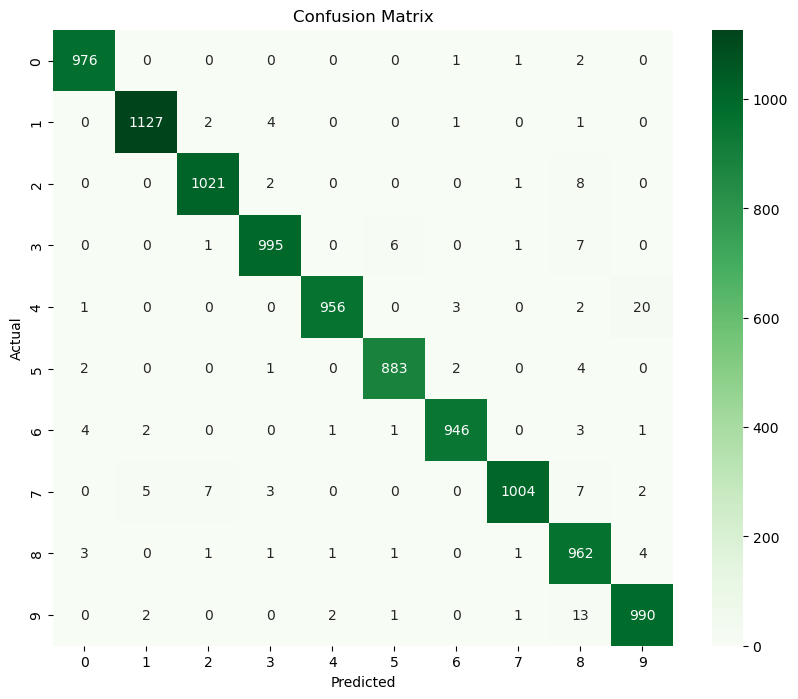

In [63]:
#1.3 -> Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

t = []
p = []

model.eval()
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        preds = torch.argmin(outputs, dim=1)
        #predictions are min distances based on model
        t.extend(targets.cpu().numpy())
        p.extend(preds.cpu().numpy())

cm = confusion_matrix(t, p)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=list(range(10)), yticklabels=list(range(10)))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

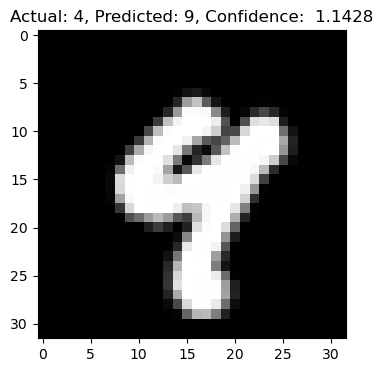

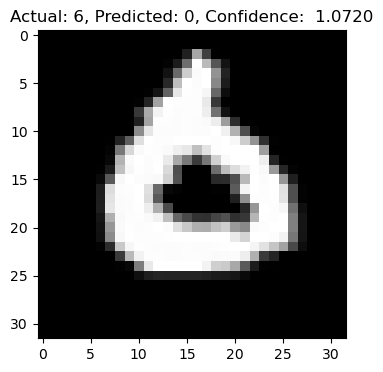

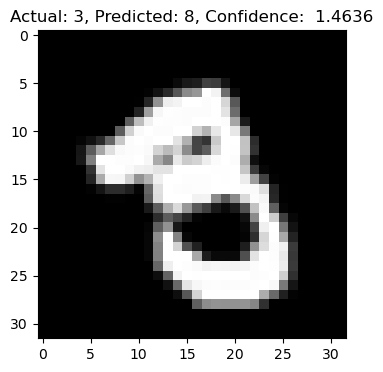

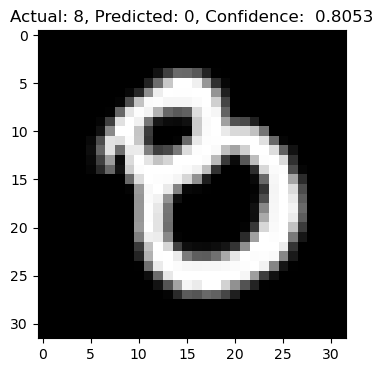

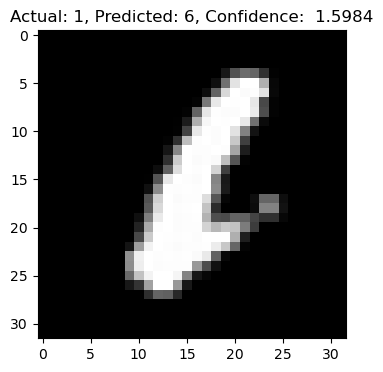

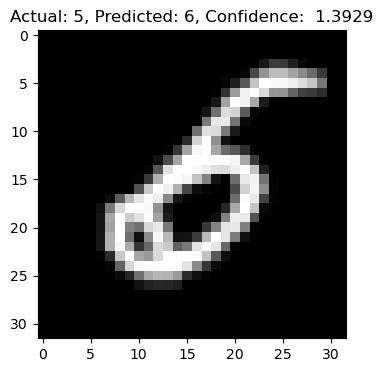

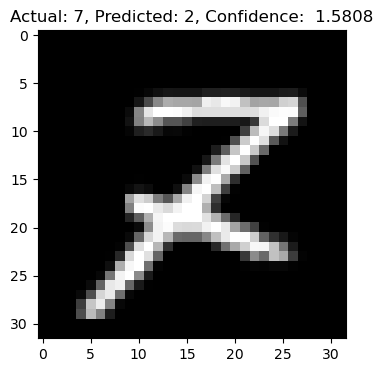

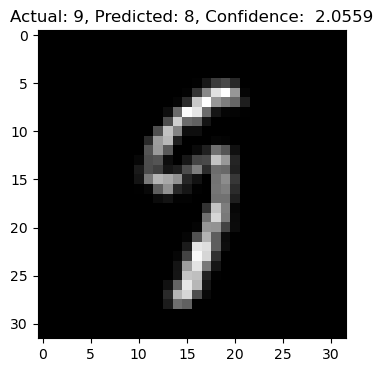

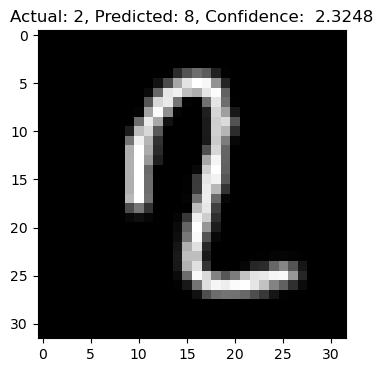

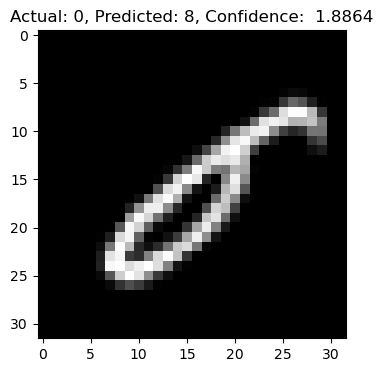

In [64]:
#1.3 -> Most "Confidently" Inaccurate
#Confidence calcualted by output of model
#If distance is smaller, considered higher confidence because goal is minimizing distance

most_inaccurate = {}

model.eval()
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        preds = torch.argmin(outputs, dim=1) #predictions decided by minimum distance to averaged bitmap in RBF

        for i in range(len(targets)):
            if preds[i] != targets[i]: #misclassified
                actual = targets[i].item()
                predicted = preds[i].item()
                confidence = -outputs[i, predicted].item() 
                #negate the distances: lower distance means high confidence!
                
                if actual not in most_inaccurate or confidence > most_inaccurate[actual][2]:
                    most_inaccurate[actual] = (inputs[i].cpu(), predicted, confidence)

for actual, (img, pred, confidence) in most_inaccurate.items(): 
    plt.figure(figsize=(8, 4))
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(f"Actual: {actual}, Predicted: {pred}, Confidence: {-confidence: .4f}")


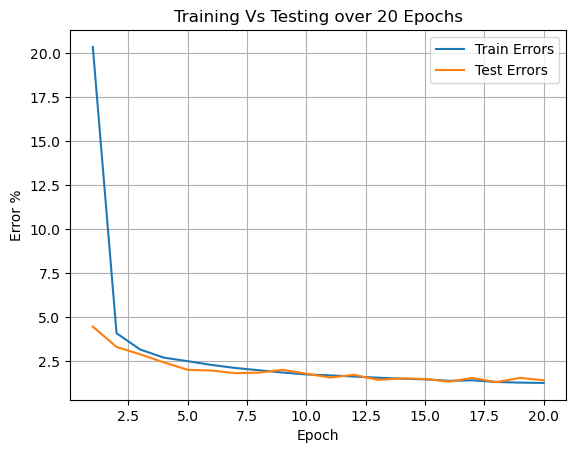

In [65]:
#plot
import matplotlib.pyplot as plt

plt.plot(range(1, epochs+1), train_errors, label="Train Errors")
plt.plot(range(1, epochs+1), test_errors, label="Test Errors")
plt.xlabel("Epoch")
plt.ylabel("Error %")
plt.title("Training Vs Testing over 20 Epochs")
plt.legend()
plt.grid()
plt.show()

In [66]:
model_path = "lenet5_rbf_model.pth"
torch.save(model, model_path)